<a href="https://colab.research.google.com/github/YoursTruly-02/Robust-Phishing-and-Homoglyph-Detection-Engine/blob/main/Robust_Phishing_and_Homoglyph_Detection_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("victusadi/phishing-urls-dataset-with-extracted-features")

print("Path to dataset files:", path)

100%|██████████| 3.97M/3.97M [00:00<00:00, 124MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/victusadi/phishing-urls-dataset-with-extracted-features/versions/1


In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import gradio as gr

In [4]:
#Locating

# 1. find the exact file name
files = os.listdir(path)
print("Files in downloaded folder:", files)

# 2.grab the first CSV file in the folder
csv_filename = [f for f in files if f.endswith('.csv')][0]
full_file_path = os.path.join(path, csv_filename)

# 3. Load the data into a Pandas DataFrame
df = pd.read_csv(full_file_path)

df.head()

Files in downloaded folder: ['phishing_features.csv']


,url,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,tld,special_char_count,digits_count,entropy
0,http://forum.uk.securebankinggroup.com/107519/...,1,89,3,0,0,5,0,2,com,4,29,4.792985
1,http://b45042.com/fish/29,1,25,1,0,0,4,0,0,com,0,7,4.003856
2,http://bet73018.com/lottery/99,1,30,1,0,0,4,0,0,com,0,7,4.053236
3,https://logiin--metsa-autho.webflow.io/,1,39,2,1,0,3,0,0,io,3,0,4.150411
4,https://mettamasklogiiann.webflow.io/,1,37,2,1,0,3,0,0,io,0,0,4.100817


In [5]:
#missing data check
total_missing = df.isnull().sum().sum()
print(f"Total missing values in the dataset: {total_missing}")
# missing values for every column
print(df.isnull().sum())

Total missing values in the dataset: 821
url                     0
label                   0
url_length              0
num_dots                0
has_https               0
has_ip                  0
num_subdirs             0
num_params              0
suspicious_words        0
tld                   821
special_char_count      0
digits_count            0
entropy                 0
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160064 entries, 0 to 160063
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   url                 160064 non-null  object 
 1   label               160064 non-null  int64  
 2   url_length          160064 non-null  int64  
 3   num_dots            160064 non-null  int64  
 4   has_https           160064 non-null  int64  
 5   has_ip              160064 non-null  int64  
 6   num_subdirs         160064 non-null  int64  
 7   num_params          160064 non-null  int64  
 8   suspicious_words    160064 non-null  int64  
 9   tld                 159243 non-null  object 
 10  special_char_count  160064 non-null  int64  
 11  digits_count        160064 non-null  int64  
 12  entropy             160064 non-null  float64
dtypes: float64(1), int64(10), object(2)
memory usage: 15.9+ MB


In [7]:
df.describe()

,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,special_char_count,digits_count,entropy
count,160064.000000,160064.000000,160064.000000,160064.000000,160064.000000,160064.000000,160064.000000,160064.000000,160064.000000,160064.000000,160064.000000
mean,0.994877,55.107382,2.998963,0.434089,0.485475,4.128436,0.221499,0.023809,1.495446,12.737036,4.246100
std,0.071391,101.782469,1.119210,0.495638,0.499791,2.090180,0.935608,0.168235,3.699627,17.420579,0.479275
min,0.000000,6.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.058814
25%,1.000000,30.000000,2.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,3.000000,3.907734
50%,1.000000,37.000000,3.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,12.000000,4.171465
75%,1.000000,65.000000,4.000000,1.000000,1.000000,4.000000,0.000000,0.000000,1.000000,16.000000,4.484850
max,1.000000,25523.000000,59.000000,1.000000,1.000000,104.000000,45.000000,3.000000,264.000000,3413.000000,6.030422


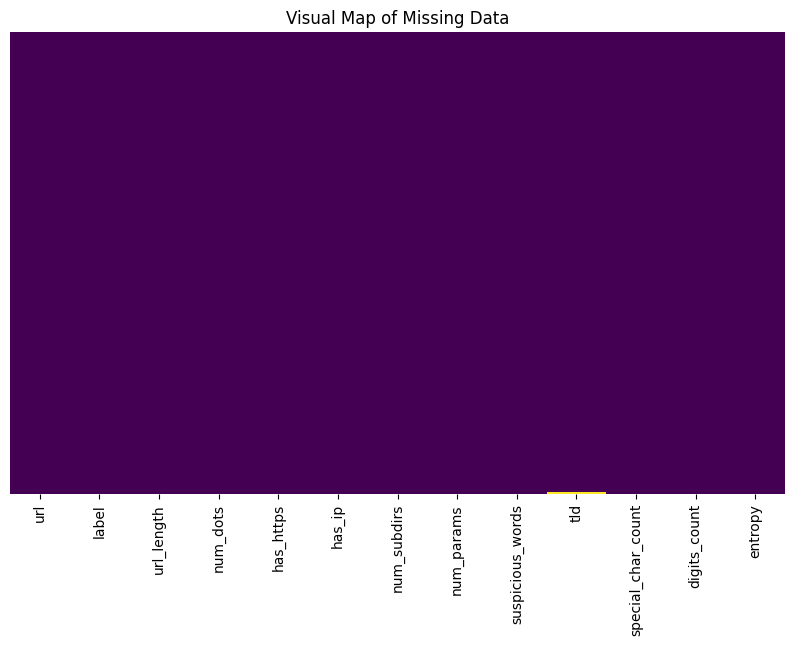

In [8]:
plt.figure(figsize=(10, 6))
# cbar=False turns off the color legend, yticklabels=False hides row numbers for speed
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Visual Map of Missing Data")
plt.show()

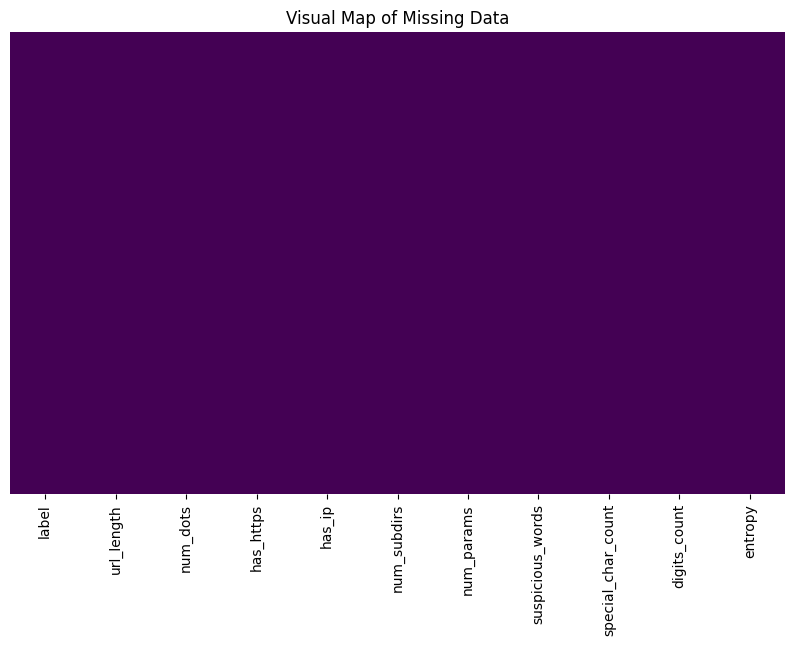

In [14]:
df1 = df.dropna().drop(columns=['url','tld'])


plt.figure(figsize=(10, 6))
# cbar=False turns off the color legend, yticklabels=False hides row numbers for speed
sns.heatmap(df1.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Visual Map of Missing Data")
plt.show()

In [15]:
df1.head()

,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,special_char_count,digits_count,entropy
0,1,89,3,0,0,5,0,2,4,29,4.792985
1,1,25,1,0,0,4,0,0,0,7,4.003856
2,1,30,1,0,0,4,0,0,0,7,4.053236
3,1,39,2,1,0,3,0,0,3,0,4.150411
4,1,37,2,1,0,3,0,0,0,0,4.100817


In [18]:
#train split

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#model1


In [ ]:
#model2
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,max_features="sqrt")

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)